## **Deep Learning Mini Project**
### Dhairya Shah (ds6969)
### Gunjan Dayani (gd2275)
### Kevin Pattni (kbp2030)

## Importing required libraries

In [1]:
import tensorflow as tf
from keras.layers import Input, Conv2D, BatchNormalization, ReLU, Add, AveragePooling2D, Flatten, Dense
from keras.models import Model
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam

# Load the CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

170498071/170498071 [==============================] - 14s 0us/step


### Implementation of a ResNet Block

In [2]:
# Define the ResNet block
def residual_block(inputs, filters, strides):
    shortcut = inputs
    x = Conv2D(filters, kernel_size=3, strides=strides, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(filters, kernel_size=3, strides=1, padding="same")(x)
    x = BatchNormalization()(x)
    if strides != 1 or inputs.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=1, strides=strides)(inputs)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([shortcut, x])
    x = ReLU()(x)
    return x

### Implementation of a ResNet architecture

In [3]:
# Define the ResNet architecture
inputs = Input(shape=(32, 32, 3))
x = Conv2D(64, kernel_size=3, strides=1, padding="same")(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)
x = residual_block(x, filters=64, strides=1)
x = residual_block(x, filters=64, strides=1)
x = residual_block(x, filters=64, strides=1)
x = residual_block(x, filters=128, strides=2)
x = residual_block(x, filters=128, strides=1)
x = residual_block(x, filters=128, strides=1)
x = residual_block(x, filters=256, strides=2)
x = residual_block(x, filters=256, strides=1)
x = residual_block(x, filters=256, strides=1)
x = AveragePooling2D(pool_size=4)(x)
x = Flatten()(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs=inputs, outputs=outputs)


### Compiling our model

In [18]:
# Compile the model
opt = Adam(lr=0.001)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.9/dist-packages/keras/optimizers/legacy/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


### Training our ResNet model with some data augmentation

In [19]:
# Data augmentation
datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

# Train the model
batch_size = 128
epochs = 100
steps_per_epoch = x_train.shape[0] // batch_size
history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size), 
                    steps_per_epoch=steps_per_epoch, epochs=epochs, 
                    validation_data=(x_test, y_test))

Epoch 1/100
390/390 [==============================] - 57s 139ms/step - loss: 0.4510 - accuracy: 0.8448 - val_loss: 0.8001 - val_accuracy: 0.7314
Epoch 2/100
390/390 [==============================] - 55s 141ms/step - loss: 0.3973 - accuracy: 0.8627 - val_loss: 0.5170 - val_accuracy: 0.8297
Epoch 3/100
390/390 [==============================] - 54s 139ms/step - loss: 0.3667 - accuracy: 0.8741 - val_loss: 0.5210 - val_accuracy: 0.8281
Epoch 4/100
390/390 [==============================] - 53s 136ms/step - loss: 0.3372 - accuracy: 0.8837 - val_loss: 0.5286 - val_accuracy: 0.8313
Epoch 5/100
390/390 [==============================] - 55s 140ms/step - loss: 0.3131 - accuracy: 0.8922 - val_loss: 0.5393 - val_accuracy: 0.8305
Epoch 6/100
390/390 [==============================] - 53s 135ms/step - loss: 0.2873 - accuracy: 0.9020 - val_loss: 0.4690 - val_accuracy: 0.8505
Epoch 7/100
390/390 [==============================] - 52s 134ms/step - loss: 0.2756 - accuracy: 0.9042 - val_loss: 0.4534 -

### The accuracy reached ~ 92% after 100 epochs.

### Visualization of ResNet model accuracy during training

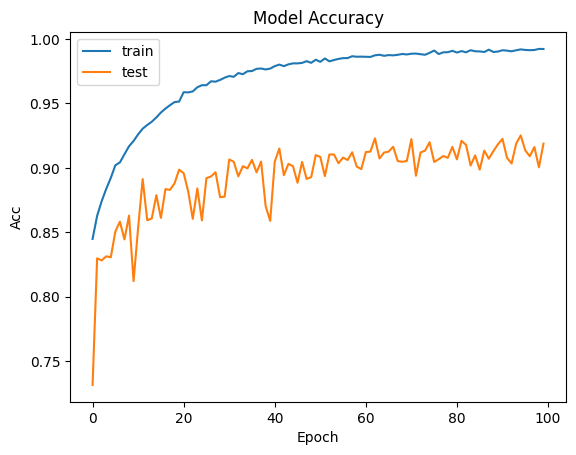

In [20]:
import matplotlib.pyplot as plt
#summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Visualization of ResNet model loss during training

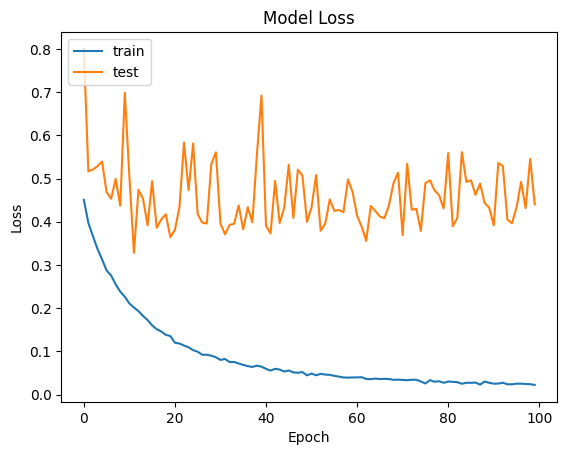

In [21]:
import matplotlib.pyplot as plt
#summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Visualizing and Evaluating Model Performance with Confusion Matrix and Classification Report

313/313 [==============================] - 3s 10ms/step


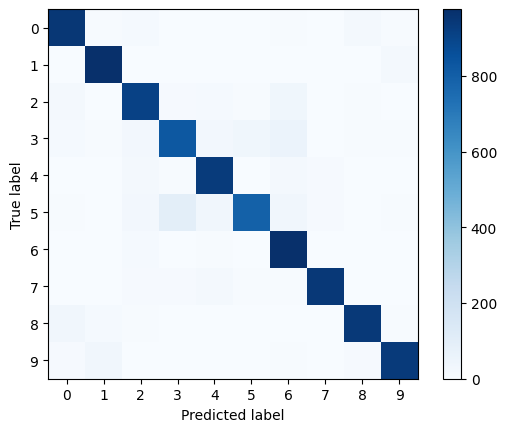

              precision    recall  f1-score   support

    airplane       0.91      0.95      0.93      1000
  automobile       0.94      0.98      0.96      1000
        bird       0.89      0.91      0.90      1000
         cat       0.86      0.83      0.84      1000
        deer       0.91      0.94      0.92      1000
         dog       0.95      0.79      0.86      1000
        frog       0.85      0.98      0.91      1000
       horse       0.97      0.94      0.96      1000
        ship       0.95      0.94      0.95      1000
       truck       0.96      0.94      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Make predictions on the test data
y_pred = np.argmax(model.predict(x_test), axis=-1)

# Generate a confusion matrix
confusion_mtx = confusion_matrix(np.argmax(y_test, axis=-1), y_pred)
plt.imshow(confusion_mtx, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# Generate a classification report
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']
print(classification_report(np.argmax(y_test, axis=-1), y_pred, target_names=class_names))

### Evaluate our model and display test accuracy

In [23]:
# Evaluate the model on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", test_acc)

313/313 - 3s - loss: 0.4401 - accuracy: 0.9188 - 3s/epoch - 11ms/step
Test accuracy: 0.9187999963760376


### Dsiplaying the number of parameters used

In [24]:
import torchvision
from torchvision import models
model = Model(inputs=inputs, outputs=outputs)
print(model.summary())

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 32, 32, 64)   1792        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 32, 32, 64)  256         ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 re_lu (ReLU)                   (None, 32, 32, 64)   0           ['batch_normalization[0][0]

### The total parameters are 4.3M which are < 5M 